## Import Required libraries

In [1]:
import operator
import functools
import pandas as pd
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Decorators
from typing import Dict, List
from typing_extensions import Annotated, TypedDict
from IPython.display import display, Markdown

# langchain packages
from langchain_core.messages import BaseMessage

# langgraph packages
from langgraph.graph import (StateGraph, 
                                START, 
                                END)
from langgraph.prebuilt import ToolNode

## Get Random Patient Information

In [2]:
# Load patient dataset
updated_patient_df = pd.read_csv('datasets/input/processed/updated_patient_df.csv')
updated_patient_df.drop('Unnamed: 0', axis = 1, inplace = True)
updated_patient_df.head(10)


# Pick a Random Patient: A female between 20 and 29 and with Pneumonia as Positive 
selected_patients = updated_patient_df[
    (updated_patient_df['Gender'] == 'Female') & \
        (updated_patient_df['Age'].between(20, 29)) & \
            (updated_patient_df['Difficulty Breathing'] == 'Yes') & \
                (updated_patient_df['Outcome Variable'] == 'Positive')]

# Choosing first patient details as our subject
selected_patients = (selected_patients
                                .reset_index(drop = True)
                                .iloc[0, :])

selected_patients = selected_patients.to_dict()
selected_patients


{'Disease': 'Influenza',
 'Fever': 'Yes',
 'Cough': 'Yes',
 'Fatigue': 'Yes',
 'Difficulty Breathing': 'Yes',
 'Age': 25,
 'Gender': 'Female',
 'Blood Pressure': 'Normal',
 'Cholesterol Level': 'Normal',
 'Outcome Variable': 'Positive',
 'First_Name': 'Amrita',
 'Last_Name': 'Nair',
 'Patient_ID': 'PAT1000000007',
 'Full_Name': 'Amrita_Nair'}

## Design Physician Agent Workflow

#### 1. Question - Patient Information

In [3]:
def question_patient(selected_patients: Dict)->str:

    # We are gonna replicate the real world situation
    # Now that we are gonna ask the patient about the symptoms, generating the response 
    # and then summarizing the response based on the patient data

    symptom_questions = {
        'Cough' : "\nAre you having any cough?\n", 
        'Fatigue': "\nAre you having any Fatigue?\n", 
        'Difficulty Breathing': "\nAre you experiencing any difficulty while breathing?\n"
    }

    # We are gonna append the question and response given by the patient
    conversations = []

    for symptom, question in symptom_questions.items():
        conversations.append(f"\nPhysician: {question}")
        response = selected_patients.get(symptom, "No")
        answer = "Yes" if response == "Yes" else "No"
        conversations.append(f"\nPatient: {answer}")

    # Now, we got the response from the patient we are gonna retrieve the patient information
    first_name = selected_patients.get('First_Name', "No Info")
    last_name = selected_patients.get('Last_Name', 'No Info')
    patient_id = selected_patients.get('Patient_ID', 'No Info')
    patient_gender = selected_patients.get('Gender', 'No Info')
    patient_age = selected_patients.get('Age', 'No Info')

    # We got the patient information and now our physician gonna summarize the information that
    # patient said till now 
    profile = f"\nYou are {first_name} {last_name}, a {patient_age} years old {patient_gender} with Patient ID : {patient_id}."
    summary = profile + "\nI gathered that the you are experiencing the following:\n"
    summaries = []
    for symptom in symptom_questions.keys():
        response = selected_patients.get(symptom, "No")
        if response == 'Yes':
            summaries.append(f'You are experiencing {symptom.lower()}')
        else:
            summaries.append(f"I'm glad you are not experienncing any {symptom.lower()}")

    # Creating the summary that physician is gonna speak
    summaries = ' ; '.join(summaries)+"." 
    summary += summaries 

    conversations.append(f"\nPhysician summarizing the conversation: {summary}")
    conversations = '\n'.join(conversations) # Concatenating the conversations 
    
    return conversations

display(Markdown(question_patient(selected_patients)))


Physician: 
Are you having any cough?


Patient: Yes

Physician: 
Are you having any Fatigue?


Patient: Yes

Physician: 
Are you experiencing any difficulty while breathing?


Patient: Yes

Physician summarizing the conversation: 
You are Amrita Nair, a 25 years old Female with Patient ID : PAT1000000007.
I gathered that the you are experiencing the following:
You are experiencing cough ; You are experiencing fatigue ; You are experiencing difficulty breathing.

#### 2. Perform Examination

In [4]:
def perform_examination(selected_patients:Dict)-> str:
    "Performs Examination by reporting fever, blood pressure and body Cholesterol Level from patient data"
    fever = selected_patients.get('Fever', 'Unknown')
    blood_pressure = selected_patients.get('Blood Pressure', "Unknown")
    cholesterol_level = selected_patients.get('Cholesterol Level', "Unknown")

    return f"Examination Results: Fever : {fever}, Blood Pressure: {blood_pressure} and Cholesterol level: {cholesterol_level}"

display(Markdown(perform_examination(selected_patients)))

Examination Results: Fever : Yes, Blood Pressure: Normal and Cholesterol level: Normal

#### 3. Dignosis Patient

In [5]:
def diagnois_patient(selected_patients:Dict)->str:
    "Provides diagnosis based on Disease and Outcome columns in patient data"
    disease = selected_patients.get('Disease', "Unknown")
    outcome = selected_patients.get('Outcome Variable', "Unknown")

    if outcome == 'Yes':
        diagnosis = "Make X-ray for Chest"
    else:
        diagnosis = "Rest to Recover"

    return f"Disease : {disease} Outcome Variable : {outcome} and Final diagnois: {diagnosis}", diagnosis


diagnois_patient(selected_patients)

('Disease : Influenza Outcome Variable : Positive and Final diagnois: Rest to Recover',
 'Rest to Recover')

#### 4. Define AgentSchema

In [6]:
class AgentState(TypedDict):
    initial_prompt : str
    messages : Annotated[List[BaseMessage], operator.add]
    question_patient : str
    examination_patient : str
    diagnosis_patient : str
    diagnosis : str    

#### 5. Define Agent Node 

In [7]:
def physician_agent_function(state, selected_patients):
    question_patients = question_patient(selected_patients)
    examination_patient = perform_examination(selected_patients)
    diagnosis_patient, diagnosis = diagnois_patient(selected_patients)

    return {'question_patient':question_patients, 
            'examination_patient':examination_patient, 
            'diagnosis_patient': diagnosis_patient, 
            'diagnosis':diagnosis}


# we have to use the functools while agent node takes any input
physician_agent_node = functools.partial(physician_agent_function, 
                                            selected_patients = selected_patients)

#### 6. Define Graph Workflow

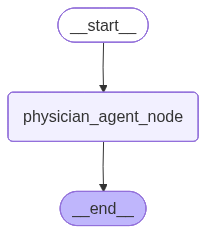

In [8]:
graph = StateGraph(AgentState)

# Adding nodes to the graph
graph.add_node("physician_agent_node", physician_agent_node)

# Adding edges to the graph
graph.add_edge(START, "physician_agent_node")
graph.add_edge("physician_agent_node", END)

graphWorkflow = graph.compile()
graphWorkflow

In [11]:
initial_prompt = """You are very experience doctor in an hospital in the netherlands. \n
                    Start a conversation with the patient and determine symptoms and give diagnosis"""

# Run the workflow
inputs = {'initial_prompt': initial_prompt}


graphWorkflow.invoke(inputs)

{'initial_prompt': 'You are very experience doctor in an hospital in the netherlands. \n\n                    Start a conversation with the patient and determine symptoms and give diagnosis',
 'messages': [],
 'question_patient': '\nPhysician: \nAre you having any cough?\n\n\nPatient: Yes\n\nPhysician: \nAre you having any Fatigue?\n\n\nPatient: Yes\n\nPhysician: \nAre you experiencing any difficulty while breathing?\n\n\nPatient: Yes\n\nPhysician summarizing the conversation: \nYou are Amrita Nair, a 25 years old Female with Patient ID : PAT1000000007.\nI gathered that the you are experiencing the following:\nYou are experiencing cough ; You are experiencing fatigue ; You are experiencing difficulty breathing.',
 'examination_patient': 'Examination Results: Fever : Yes, Blood Pressure: Normal and Cholesterol level: Normal',
 'diagnosis_patient': 'Disease : Influenza Outcome Variable : Positive and Final diagnois: Rest to Recover',
 'diagnosis': 'Rest to Recover'}